<a href="https://colab.research.google.com/github/Sabbir0412/mainflowtask3/blob/main/assign_01_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os

DRIVE = "/content/drive/MyDrive"

print("ZIP files found in Google Drive:\n")

for root, dirs, files in os.walk(DRIVE):
    for file in files:
        if file.lower().endswith(".zip"):
            full_path = os.path.join(root, file)
            print(full_path)

ZIP files found in Google Drive:

/content/drive/MyDrive/images.zip
/content/drive/MyDrive/Colab Notebooks/images.zip


In [7]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/images.zip"
extract_path = "/content/cv_images"

# Extract only if the folder doesn't already exist
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Images extracted successfully.")
else:
    print("Images are already extracted.")

# Show the extracted files
print("\nFiles inside the extracted folder:\n")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Images extracted successfully.

Files inside the extracted folder:

/content/cv_images/06_edges_and_geometric_shapes.png
/content/cv_images/03_noisy_image.png
/content/cv_images/05_binary_shapes_with_noise.png
/content/cv_images/07_perspective_document.png
/content/cv_images/08_stereo_left.png
/content/cv_images/README.txt
/content/cv_images/01_general_color_scene.png
/content/cv_images/09_stereo_right.png
/content/cv_images/02_low_contrast.png
/content/cv_images/10_radiometry_intensity_levels.png
/content/cv_images/04_uneven_illumination_document.png
/content/cv_images/camera_calibration_chessboards/chessboard_view_01.png
/content/cv_images/camera_calibration_chessboards/chessboard_view_02.png
/content/cv_images/camera_calibration_chessboards/chessboard_view_04.png
/content/cv_images/camera_calibration_chessboards/chessboard_view_03.png
/content/cv_images/camera_calibration_chessboards/chessboard_view_05.png


Height   : 640
Width    : 960
Channels : 3
Data type: uint8


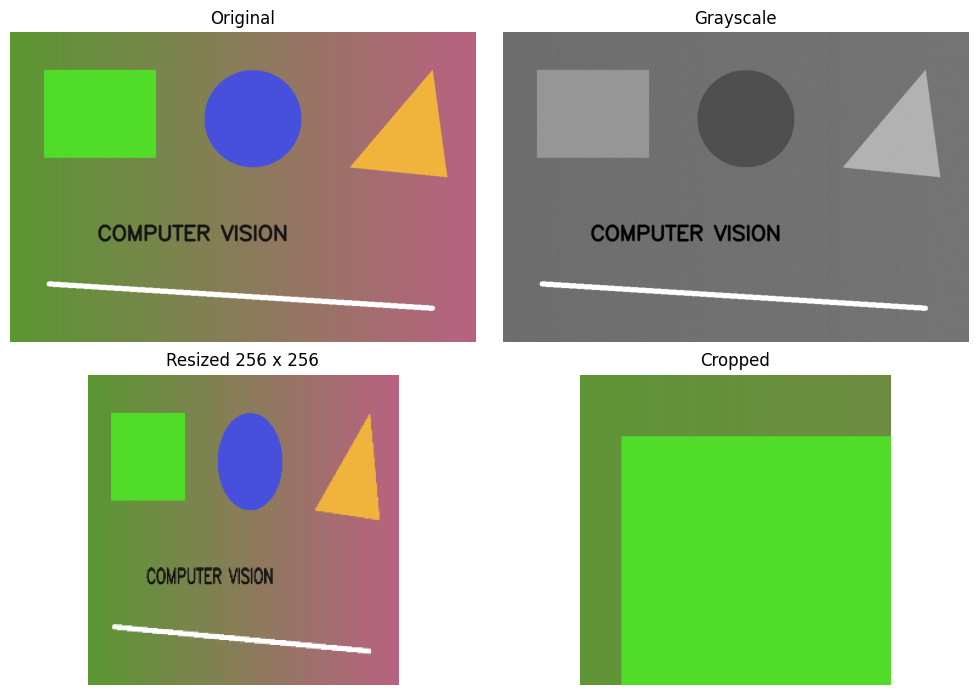

In [12]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/01_general_color_scene.png")

if image is None:
    raise FileNotFoundError("Image not found.")

print("Height   :", image.shape[0])
print("Width    :", image.shape[1])
print("Channels :", image.shape[2])
print("Data type:", image.dtype)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(rgb, (256, 256))
cropped = rgb[50:200, 50:200]

plt.figure(figsize=(10, 7))

plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(resized)
plt.title("Resized 256 x 256")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cropped)
plt.title("Cropped")
plt.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1650/1045172051.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0, 256])
/tmp/ipykernel_1650/1045172051.py:41: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0, 256])
/tmp/ipykernel_1650/1045172051.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(clahe_image.ravel(), 256, [0, 256])


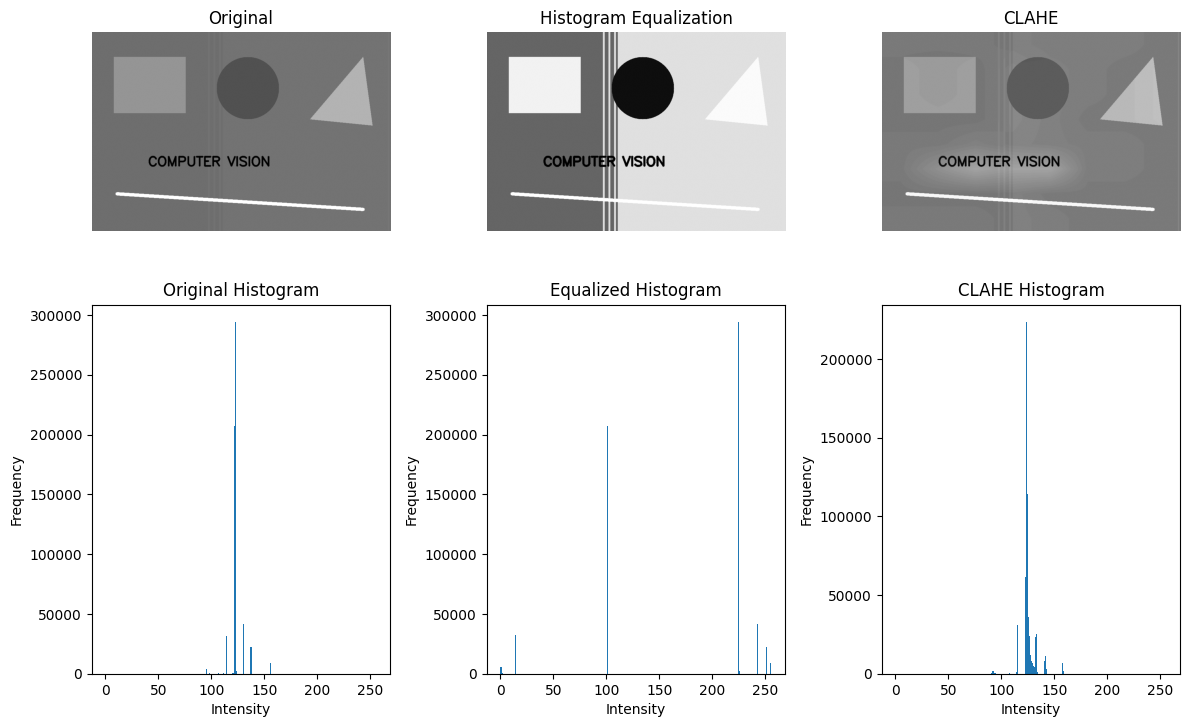

In [13]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/02_low_contrast.png", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found.")

# Histogram Equalization
equalized = cv2.equalizeHist(image)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_image = clahe.apply(image)

# Display images and histograms
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.hist(image.ravel(), 256, [0, 256])
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 3, 5)
plt.hist(equalized.ravel(), 256, [0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 3, 6)
plt.hist(clahe_image.ravel(), 256, [0, 256])
plt.title("CLAHE Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

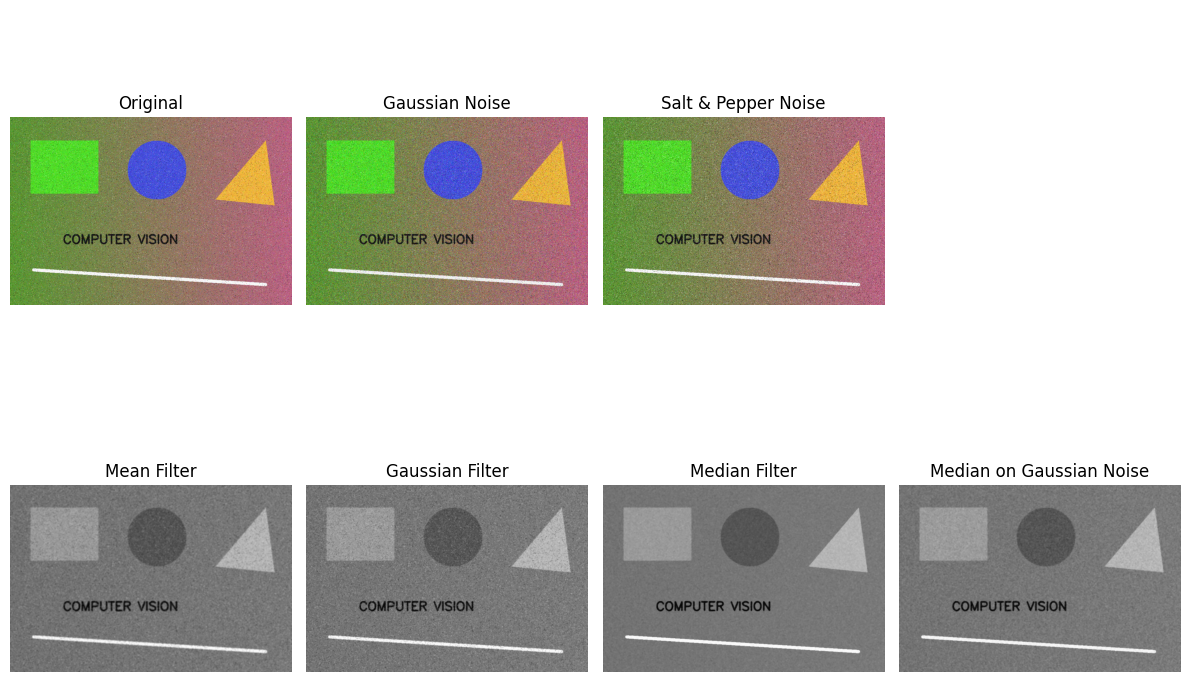

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/03_noisy_image.png")

if image is None:
    raise FileNotFoundError("Image not found.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Add Gaussian noise
gaussian_noise = np.random.normal(0, 25, image.shape)
gaussian_noisy = np.clip(image.astype(np.float32) + gaussian_noise, 0, 255).astype(np.uint8)

# Add salt-and-pepper noise
sp_noisy = image.copy()
prob = 0.03

random = np.random.rand(image.shape[0], image.shape[1])

sp_noisy[random < prob / 2] = 0
sp_noisy[random > 1 - prob / 2] = 255

# Convert to grayscale for filtering
gaussian_gray = cv2.cvtColor(gaussian_noisy, cv2.COLOR_RGB2GRAY)
sp_gray = cv2.cvtColor(sp_noisy, cv2.COLOR_RGB2GRAY)

# Apply filters
mean_gaussian = cv2.blur(gaussian_gray, (5, 5))
gaussian_filtered = cv2.GaussianBlur(gaussian_gray, (5, 5), 0)
median_gaussian = cv2.medianBlur(gaussian_gray, 5)

mean_sp = cv2.blur(sp_gray, (5, 5))
gaussian_sp = cv2.GaussianBlur(sp_gray, (5, 5), 0)
median_sp = cv2.medianBlur(sp_gray, 5)

# Display results
plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(gaussian_noisy)
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(sp_noisy)
plt.title("Salt & Pepper Noise")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(mean_sp, cmap="gray")
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(gaussian_sp, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(median_sp, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(median_gaussian, cmap="gray")
plt.title("Median on Gaussian Noise")
plt.axis("off")

plt.tight_layout()
plt.show()

Otsu threshold value: 186.0


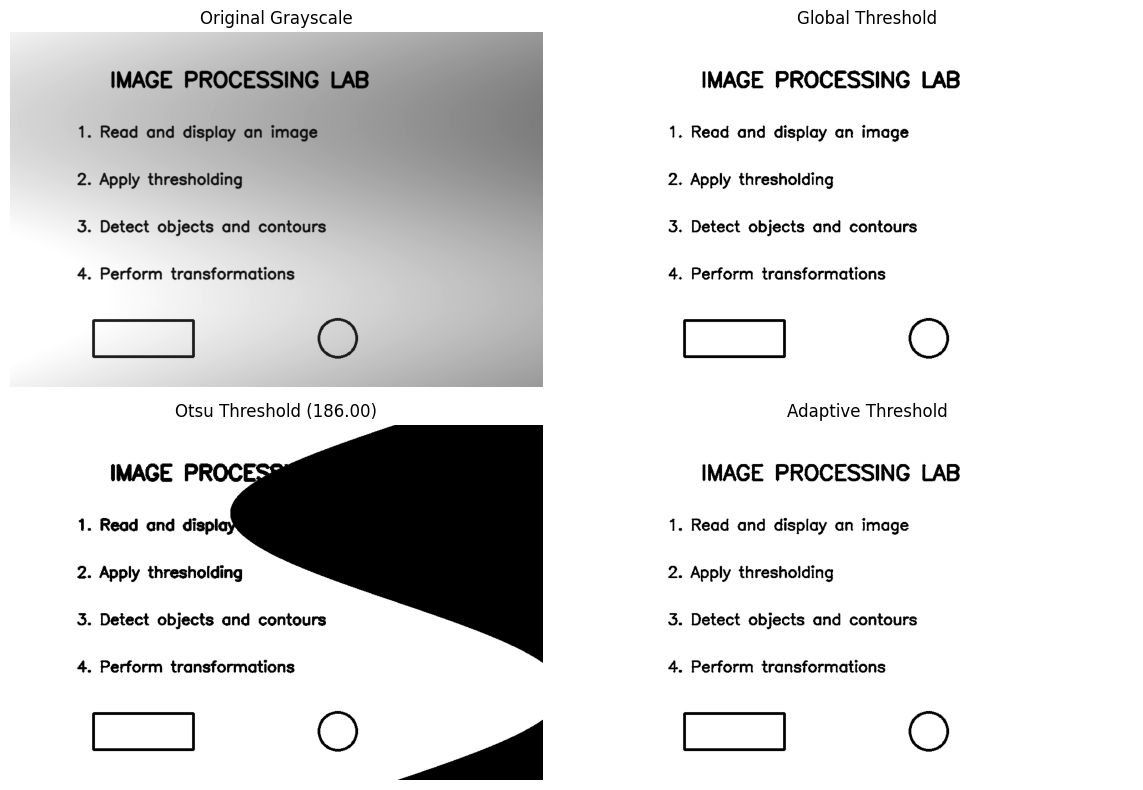

In [15]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/04_uneven_illumination_document.png", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found.")

# Global thresholding
_, global_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Otsu thresholding
otsu_value, otsu_thresh = cv2.threshold(
    image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

print("Otsu threshold value:", otsu_value)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title(f"Otsu Threshold ({otsu_value:.2f})")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

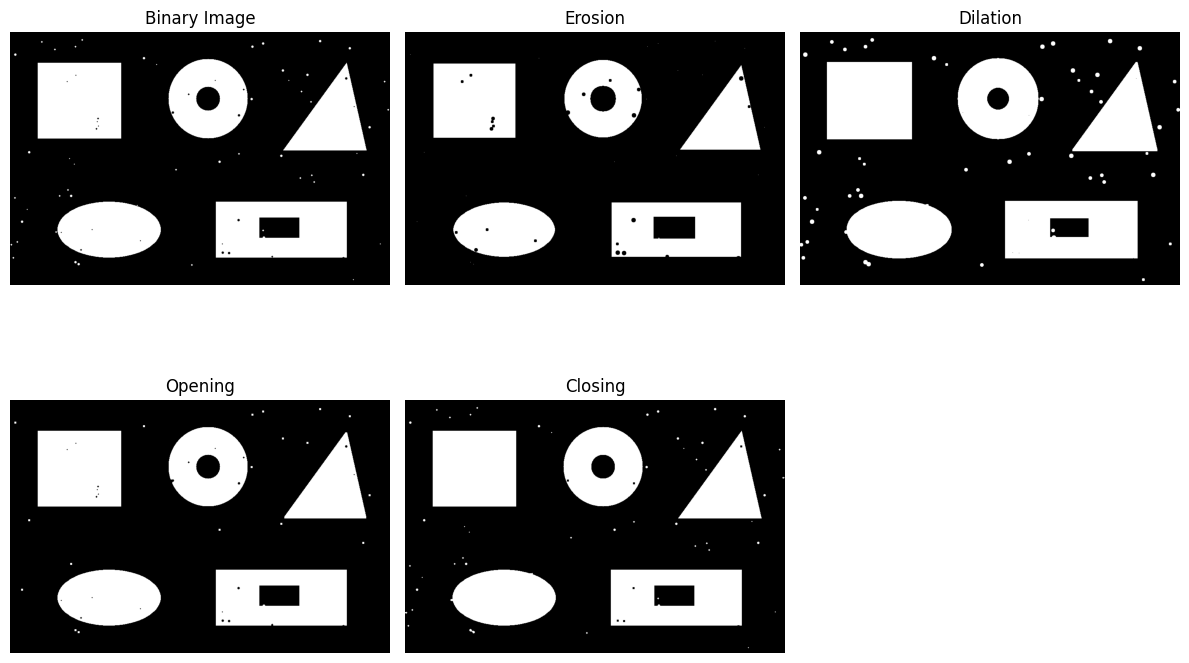

In [16]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/05_binary_shapes_with_noise.png", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found.")

# Convert to binary
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Structuring element
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# Morphological operations
erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

Object 1
  Area       : 46177.00
  Perimeter  : 953.80
  Centroid   : (684, 499)
  Bounding Box: x=520, y=430, width=331, height=141

Object 2
  Area       : 28605.50
  Perimeter  : 686.40
  Centroid   : (250, 499)
  Bounding Box: x=120, y=430, width=261, height=141

Object 3
  Area       : 23095.00
  Perimeter  : 736.98
  Centroid   : (813, 226)
  Bounding Box: x=690, y=80, width=211, height=221

Object 4
  Area       : 39900.00
  Perimeter  : 800.00
  Centroid   : (175, 175)
  Bounding Box: x=70, y=80, width=211, height=191

Object 5
  Area       : 31134.00
  Perimeter  : 661.75
  Centroid   : (500, 170)
  Bounding Box: x=400, y=70, width=201, height=201

Total objects detected: 5


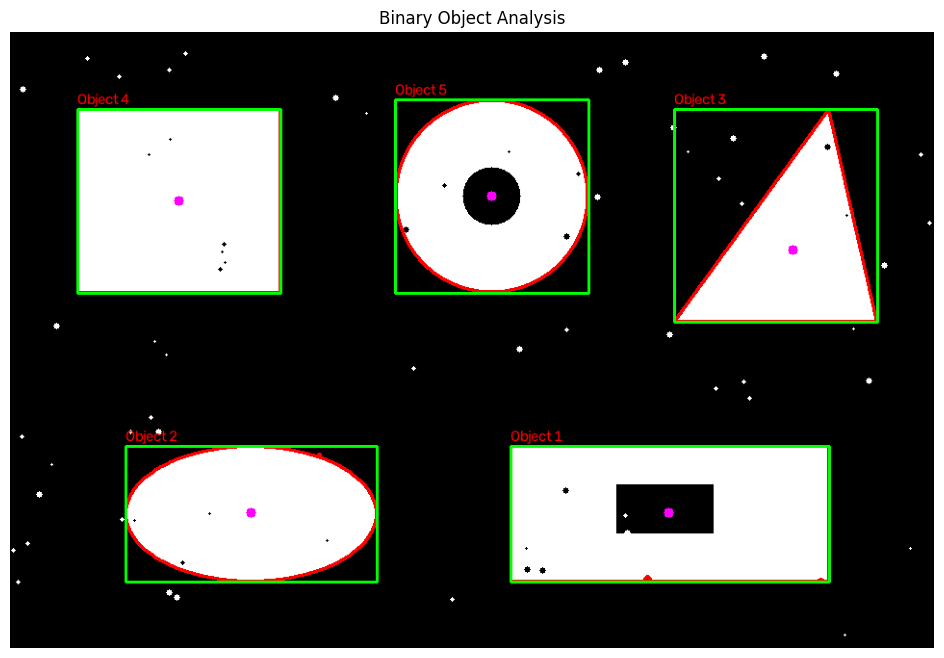

In [17]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/05_binary_shapes_with_noise.png", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found.")

_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)

object_number = 0

for contour in contours:

    area = cv2.contourArea(contour)

    # Ignore very small noise
    if area < 50:
        continue

    object_number += 1

    perimeter = cv2.arcLength(contour, True)

    moments = cv2.moments(contour)

    if moments["m00"] != 0:
        cx = int(moments["m10"] / moments["m00"])
        cy = int(moments["m01"] / moments["m00"])
    else:
        cx, cy = 0, 0

    x, y, w, h = cv2.boundingRect(contour)

    print(f"Object {object_number}")
    print(f"  Area       : {area:.2f}")
    print(f"  Perimeter  : {perimeter:.2f}")
    print(f"  Centroid   : ({cx}, {cy})")
    print(f"  Bounding Box: x={x}, y={y}, width={w}, height={h}")
    print()

    # Draw contour
    cv2.drawContours(output, [contour], -1, (255, 0, 0), 2)

    # Draw bounding box
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Draw centroid
    cv2.circle(output, (cx, cy), 5, (255, 0, 255), -1)

    # Object number
    cv2.putText(
        output,
        f"Object {object_number}",
        (x, max(y - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

print("Total objects detected:", object_number)

plt.figure(figsize=(12, 8))
plt.imshow(output)
plt.title("Binary Object Analysis")
plt.axis("off")
plt.show()

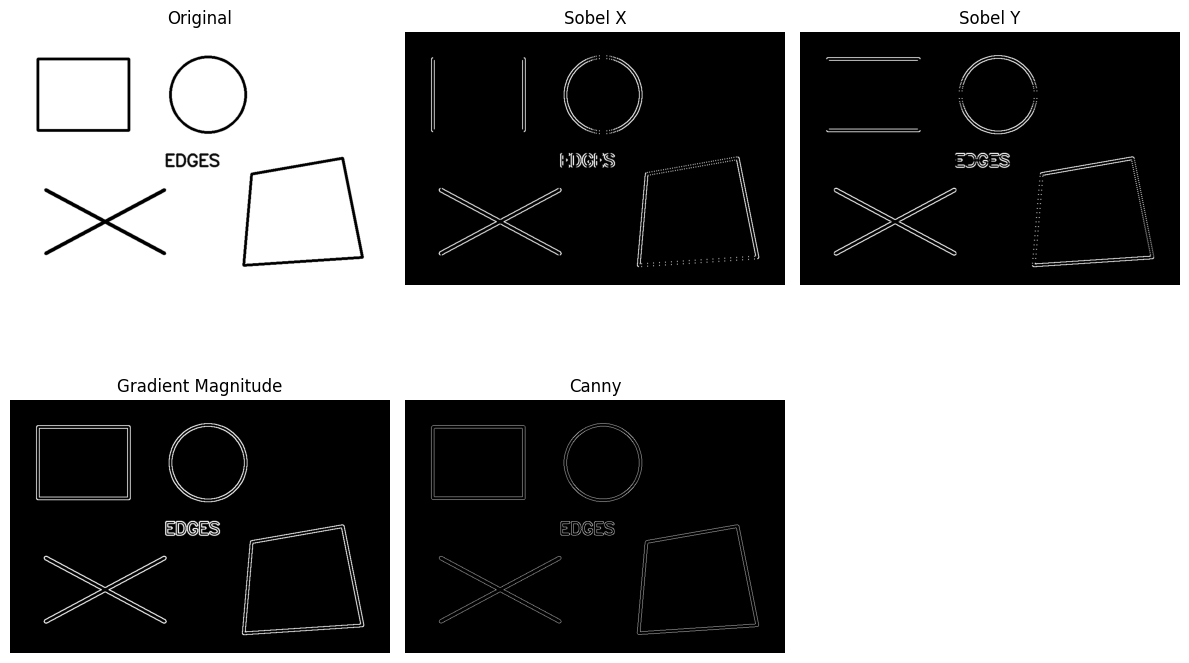

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/06_edges_and_geometric_shapes.png", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found.")

# Sobel X
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)

# Sobel Y
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude
gradient = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)

gradient = cv2.convertScaleAbs(gradient)

# Canny
canny = cv2.Canny(image, 100, 200)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(cv2.convertScaleAbs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(cv2.convertScaleAbs(sobel_y), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gradient, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

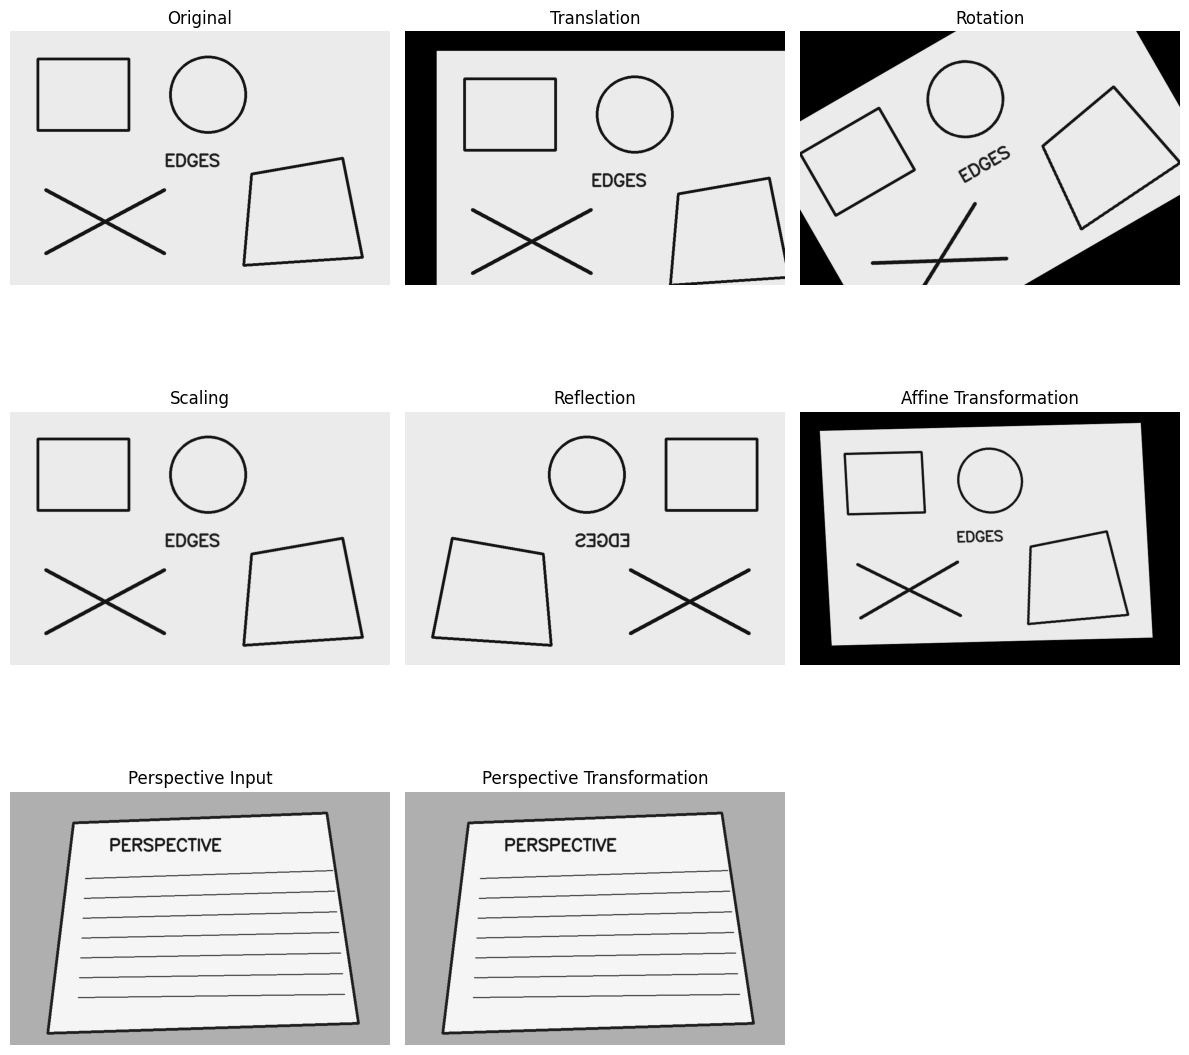

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/content/cv_images/06_edges_and_geometric_shapes.png")

if image is None:
    raise FileNotFoundError("Image not found.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

# Translation
translation_matrix = np.float32([
    [1, 0, 80],
    [0, 1, 50]
])

translated = cv2.warpAffine(
    image,
    translation_matrix,
    (w, h)
)

# Rotation
rotation_matrix = cv2.getRotationMatrix2D(
    (w // 2, h // 2),
    30,
    1
)

rotated = cv2.warpAffine(
    image,
    rotation_matrix,
    (w, h)
)

# Scaling
scaled = cv2.resize(
    image,
    None,
    fx=1.5,
    fy=1.5
)

# Reflection
reflected = cv2.flip(image, 1)

# Affine transformation
source_points = np.float32([
    [0, 0],
    [w - 1, 0],
    [0, h - 1]
])

destination_points = np.float32([
    [50, 50],
    [w - 100, 30],
    [80, h - 50]
])

affine_matrix = cv2.getAffineTransform(
    source_points,
    destination_points
)

affine = cv2.warpAffine(
    image,
    affine_matrix,
    (w, h)
)

# Perspective transformation
document = cv2.imread(
    "/content/cv_images/07_perspective_document.png"
)

if document is None:
    raise FileNotFoundError("Perspective document image not found.")

document = cv2.cvtColor(document, cv2.COLOR_BGR2RGB)

dh, dw = document.shape[:2]

src = np.float32([
    [0, 0],
    [dw - 1, 0],
    [dw - 1, dh - 1],
    [0, dh - 1]
])

dst = np.float32([
    [0, 0],
    [dw - 1, 0],
    [dw - 1, dh - 1],
    [0, dh - 1]
])

# Perspective correction using the image corners
perspective_matrix = cv2.getPerspectiveTransform(src, dst)

perspective = cv2.warpPerspective(
    document,
    perspective_matrix,
    (dw, dh)
)

plt.figure(figsize=(12, 12))

plt.subplot(3, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(translated)
plt.title("Translation")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(rotated)
plt.title("Rotation")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(scaled)
plt.title("Scaling")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(reflected)
plt.title("Reflection")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(document)
plt.title("Perspective Input")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(perspective)
plt.title("Perspective Transformation")
plt.axis("off")

plt.tight_layout()
plt.show()

Calibration images found: 5
Corners detected: chessboard_view_01.png
Corners detected: chessboard_view_02.png
Corners detected: chessboard_view_03.png
Corners detected: chessboard_view_04.png
Corners detected: chessboard_view_05.png

Successfully detected corners in: 5 images

Camera Intrinsic Matrix:
[[6.27072899e+03 0.00000000e+00 6.49146136e+02]
 [0.00000000e+00 6.52134340e+03 3.00419431e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
[[-2.82028839e+00  1.45985329e+03  5.05198510e-03 -8.37809135e-02
  -2.22840722e+05]]

Rotation Vectors:
Image 1:
[[0.26938148]
 [0.04262939]
 [0.01128544]]
Image 2:
[[ 0.4059592 ]
 [-0.07212503]
 [ 0.11619063]]
Image 3:
[[-0.38295877]
 [-0.20997874]
 [-0.14342958]]
Image 4:
[[-0.47987471]
 [ 0.07690065]
 [ 0.13266012]]
Image 5:
[[-0.42293067]
 [-0.55501352]
 [-0.14008649]]

Translation Vectors:
Image 1:
[[ -6.73973127]
 [ -2.15000889]
 [103.04314925]]
Image 2:
[[-6.41706761]
 [-2.38290146]
 [96.52926544]]
Image 3:
[[-6.

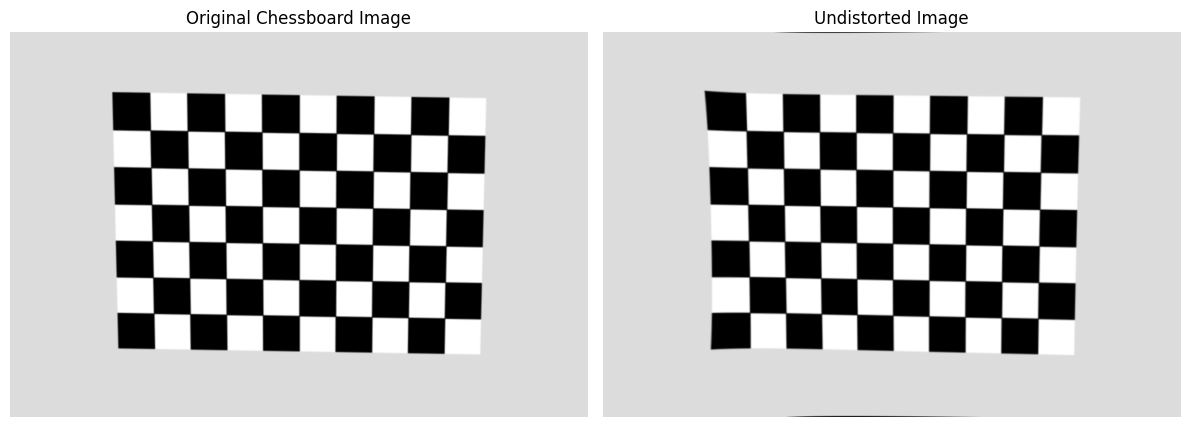

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Find chessboard images
images = sorted(
    glob.glob(
        "/content/cv_images/camera_calibration_chessboards/chessboard_view_*.png"
    )
)

if len(images) == 0:
    raise FileNotFoundError("Chessboard images were not found.")

print("Calibration images found:", len(images))

# Number of inner corners in the chessboard
pattern_size = (9, 6)

# 3D coordinates of chessboard corners
object_points_template = np.zeros(
    (pattern_size[0] * pattern_size[1], 3),
    np.float32
)

object_points_template[:, :2] = np.mgrid[
    0:pattern_size[0],
    0:pattern_size[1]
].T.reshape(-1, 2)

object_points = []
image_points = []

gray = None

# Detect chessboard corners
for filename in images:

    image = cv2.imread(filename)

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    found, corners = cv2.findChessboardCorners(
        gray,
        pattern_size,
        None
    )

    if found:

        criteria = (
            cv2.TERM_CRITERIA_EPS +
            cv2.TERM_CRITERIA_MAX_ITER,
            30,
            0.001
        )

        corners = cv2.cornerSubPix(
            gray,
            corners,
            (11, 11),
            (-1, -1),
            criteria
        )

        object_points.append(object_points_template.copy())
        image_points.append(corners)

        print("Corners detected:", os.path.basename(filename))

print("\nSuccessfully detected corners in:", len(object_points), "images")

if len(object_points) == 0:
    raise ValueError("No chessboard corners were detected.")

# Camera calibration
ret, camera_matrix, distortion, rvecs, tvecs = cv2.calibrateCamera(
    object_points,
    image_points,
    gray.shape[::-1],
    None,
    None
)

print("\nCamera Intrinsic Matrix:")
print(camera_matrix)

print("\nDistortion Coefficients:")
print(distortion)

print("\nRotation Vectors:")
for i, rvec in enumerate(rvecs, 1):
    print(f"Image {i}:\n{rvec}")

print("\nTranslation Vectors:")
for i, tvec in enumerate(tvecs, 1):
    print(f"Image {i}:\n{tvec}")

# ------------------------------------------------------------
# Mean reprojection error
# ------------------------------------------------------------

total_error = 0.0

for i in range(len(object_points)):

    projected_points, _ = cv2.projectPoints(
        object_points[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        distortion
    )

    # Convert both arrays to the same shape and type
    detected = image_points[i].reshape(-1, 2).astype(np.float64)
    projected = projected_points.reshape(-1, 2).astype(np.float64)

    error = np.mean(
        np.linalg.norm(detected - projected, axis=1)
    )

    total_error += error

mean_error = total_error / len(object_points)

print("\nMean Reprojection Error:", mean_error)

# ------------------------------------------------------------
# Undistort the first calibration image
# ------------------------------------------------------------

test_image = cv2.imread(images[0])

undistorted = cv2.undistort(
    test_image,
    camera_matrix,
    distortion
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title("Original Chessboard Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.title("Undistorted Image")
plt.axis("off")

plt.tight_layout()
plt.show()

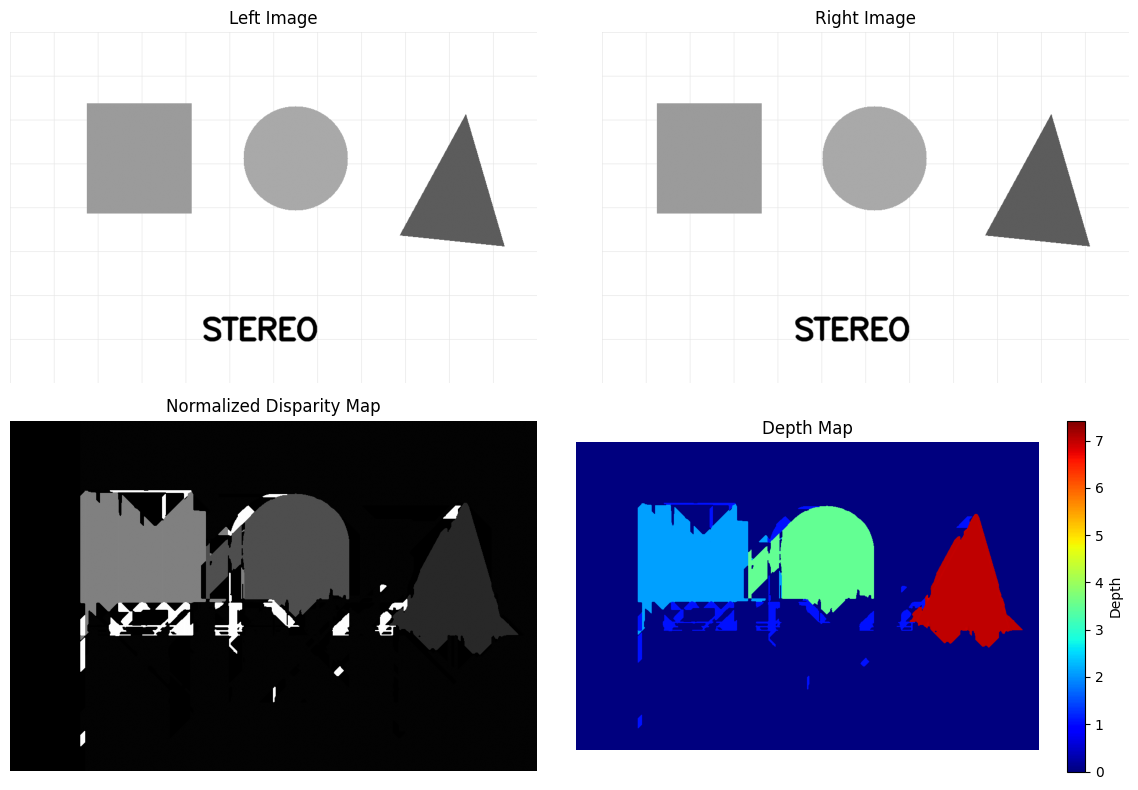

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

left = cv2.imread(
    "/content/cv_images/08_stereo_left.png",
    cv2.IMREAD_GRAYSCALE
)

right = cv2.imread(
    "/content/cv_images/09_stereo_right.png",
    cv2.IMREAD_GRAYSCALE
)

if left is None or right is None:
    raise FileNotFoundError("Stereo images not found.")

# StereoSGBM
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16 * 8,
    blockSize=5,
    P1=8 * 1 * 5**2,
    P2=32 * 1 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)

disparity = stereo.compute(left, right).astype(np.float32) / 16.0

# Normalize disparity for display
disparity_display = cv2.normalize(
    disparity,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# Assumed camera parameters
# Replace with actual calibrated values if provided.
focal_length = 700.0
baseline = 0.12

# Depth = focal_length * baseline / disparity
depth = np.zeros_like(disparity, dtype=np.float32)

valid = disparity > 0
depth[valid] = (
    focal_length * baseline / disparity[valid]
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(left, cmap="gray")
plt.title("Left Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(right, cmap="gray")
plt.title("Right Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(disparity_display, cmap="gray")
plt.title("Normalized Disparity Map")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(depth, cmap="jet")
plt.colorbar(label="Depth")
plt.title("Depth Map")
plt.axis("off")

plt.tight_layout()
plt.show()